# HW 6: Character classification using NNs with PyTorch
The dataset we'll play with is from University of California, Irvine (UCI) and contains a bunch of images of letters of various fonts. Some printed + scanned, some the values screen-capped from a computer. The images are 20x20 pixels, grayscale.

## Step 1: Data acquisition + cleanup

The data is unfortunately in a really, really horrible format for us. We're going to throw away basically everything except for the m_label field (the unicode codepoint for the character, which is the same as the ascii value for basic alphanumeric characters) and the pixel values which are scattered across 400 columns labeled rxcy (where x and y are the row and column numbers that range from 0 to 19).

To Start, write a function that transforms a dataframe and returns 2 numpy arrays: Xs which is a #samples x 20 x 20 array containing the pixel values, and Ys which is a #samples x 1 array containing the ascii vales for each character. You should normalize the Xs array so the values go from 0-1 (probably this requires dividing by 256 or using the scale function from A5)

For our labels, we'll need to do a little bit of preprocessing as well. While we COULD use the ascii/unicode values of the characters as our label, this wouldn't work very well becuase we'd basically need to have outputs from 0 up to the max number, even though a lot of those won't have corresponding characters in the dataset. This is especially true for fonts that have high unicode code-point characters in them. To make our lives easier, we'll want to assign each character a smaller index value. I suggest making dictionaries to convert from unicode number to label index and vice versa, which will be basically the same as we did for words in the NLP with Neural Nets code.

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
data = pd.read_csv("ENGLISH.csv")
print(data.head())
   
def extractImagesAndLabels(data):
    # Extract label column
    Ys = data['m_label'].values.astype(np.int64)

    # Extract pixel columns
    pixelColumns = [col for col in data.columns if col.startswith('r')]
    Xs = data[pixelColumns].values.astype(np.float32)

    # Normalize pixel values (0–1 range)
    Xs /= 255.0
    print(np.isnan(Xs).any())
    print(np.isinf(Xs).any())
    Xs = Xs.reshape(-1, 20, 20)
    return Xs, Ys

def createLabelMaps(Ys):
    # Ys = 41, 42, 41, 43
    # Keep only the unique acii values in Ys
    uniqueLabels = sorted(set(Ys))
    # Create a mapping from each unique ASCII value to a new label index starting at 0
    # For example if Ys contains 41, 42, and 42, then the mapping of the dictionary will be: 41: 0, 42: 1, 43: 2
    labelToIdx = {label: idx for idx, label in enumerate(uniqueLabels)}
    # Vice versa mapping from index to label
    idxToLabel = {idx: label for label, idx in labelToIdx.items()}

    # mappedYs = []
    # for y in Ys:
    #     mappedYs.append(labelToIdx[y])
    # mappedYs = np.array(mappedYs)
    mappedYs = np.array([labelToIdx[y] for y in Ys])

    # [41, 42, 41, 43] -> [0, 1, 0, 2] (mappedYs)
    return mappedYs, labelToIdx, idxToLabel

Xs, YsAscii = extractImagesAndLabels(data)
Ys, labelToIdx, idxToLabel = createLabelMaps(YsAscii)
print("Xs shape: ", Xs.shape)   # expecting: num_samples,20,20
print("Ys shape: ", Ys.shape)   # expecting: num_samples,
print("Number of classes: ", len(labelToIdx))
label_counts = Counter(Ys)
for index, count in label_counts.items():
    print(f"  Class {index:3d} (char '{chr(idxToLabel[index])}'): {count} samples")




      font          fontVariant  m_label  strength  italic  orientation  \
0  ENGLISH  OLD ENGLISH TEXT MT    64258       0.4       0          0.0   
1  ENGLISH  OLD ENGLISH TEXT MT    64257       0.4       0          0.0   
2  ENGLISH  OLD ENGLISH TEXT MT    61442       0.4       0          0.0   
3  ENGLISH  OLD ENGLISH TEXT MT    61441       0.4       0          0.0   
4  ENGLISH  OLD ENGLISH TEXT MT     9674       0.4       0          0.0   

   m_top  m_left  originalH  originalW  ...  r19c10  r19c11  r19c12  r19c13  \
0     38      21         47         33  ...       1       1       1       3   
1     38      21         47         30  ...       1       1       1      26   
2     38      21         47         33  ...       1       1       1       3   
3     38      21         47         30  ...       1       1       1      26   
4     38      21         47         29  ...     113       2       1       1   

   r19c14  r19c15  r19c16  r19c17  r19c18  r19c19  
0      88     213     

## Step 2: Build a Pytorch network
We're going to use the Pytorch library, like we've seen in class, to build/train our network. Check out the notebooks we've made in class or the official documentation/tutorials.

To start with, we're going to use a model very similar to the MNIST CNN we used in class. It will consist of:

a Convolution2D layer with relu activations
a max pooling layer
another convolution layer
another max pooling layer
a dense layer with relu activation
a dense layer
Compile and train your network like we did in class. You'll probably have to use the np.reshape function on your data to make Pytorch happy. I reshaped my X values like np.reshape(Xs, (-1, 1, 20, 20)) to get them in the right format.

For training, you'll want to check out torch.utils.data.DataLoader which can take a TensorDataset so you can iterate over batches like we did in class for the MNIST data.

In [2]:
import torchvision
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as transforms

import torch.optim as optim
from torch.utils.data.dataloader import default_collate
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Batch size, channel size, height, width
XsReshaped = Xs.reshape(-1, 1, 20, 20).astype(np.float32)

# Split into train/test sets
XTrain, XTest, yTrain, yTest = train_test_split(XsReshaped, Ys, test_size=0.2, random_state=42)

# Convert numpy arrays to PyTorch tensors (Multidemensional arrays)
XTrainTensor = torch.tensor(XTrain)
yTrainTensor = torch.tensor(yTrain)
XTestTensor = torch.tensor(XTest)
yTestTensor = torch.tensor(yTest)

# Wrap in TensorDataset and DataLoader
# Match image with label 
trainDataset = TensorDataset(XTrainTensor, yTrainTensor)
testDataset = TensorDataset(XTestTensor, yTestTensor)
# Load data and get into the right format for batch processing
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32)



In [3]:
import torch.nn as nn
import torch.nn.functional as F

epochs_ = 30
numclasses = len(labelToIdx)  # Number of unique labels/classes

class Net(nn.Module):
    def __init__(self,numclasses):
        super(Net, self).__init__()

        # number of 3x3 filters that will pass in the first convolution layer 
        c1Out = 128 # convoluation layer 1 will output x "images": one for each filter it trains
        
        c2Out = 256  #x2

        # This is the first convolutional layer. It take our reshaped 20x20 (grayscale) images, and applies the number of filters specified by c1Out each of size 3x3 pixels.
        # The input is 1 channel (grayscale), and the output will be c1Out channels (6 for now)
        self.conv1 = nn.Conv2d(1, c1Out, 3) 
        # This takes oue 20 x 20 image and applies a 3x3 filter to it, outputting an 18x18 image for each of the x about of c1Out filters
        # print(self.conv1)
    
        # First max pooling layer, downsamples --> taking the maximum value in each 2x2 block of pixels from our 18 x 18 image
        # This will reduce the size of the image to 9x9
        self.pool = nn.MaxPool2d(2, 2) 
        # Now we have x (c1Out (6)) 9x9 images, meaning we have 6 * 9 * 9 = 486 features of data to work wwith
        
        # Second convolutional layer, which takes the 6 9x9 images and applies c2Out (x2 or 16) filters of size 3x3 to them. #channel = number of images output by prev filters 
        self.conv2 = nn.Conv2d(c1Out, c2Out, 3) 
        # This will output 7x7 images for each of the c2Out filters, so we have 16 7x7 images
        # 16 feature maps -- 49 x 16 = 784 features
        
        
        #this is tricky.  The convolutions each shave 1 pixel off around the border, and then the
        #max pools reduce the number of pixels by 4
        self.pooledOutputSize = c2Out * 3 * 3 #  outputs per image whose size has been reduced size = 144 features --> flattening 3D tensor into 1D vector 
        # fcs are the fully connected layers that take the features and pass them through a dense layer
        self.fc1 = nn.Linear(self.pooledOutputSize, 120) # take the 144 or pooledOutputSize features and pass them through a dense layer with 120 outputs/neurons
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, numclasses)


    def forward(self, x): # "batch" of images [batchSize, 1, 20, 20]
        #x is 4D tensor:  (batch size, width, height, #channels (1, grayscale image))
        
        # print(x.shape)
        
        # First convolution layer - should should get an output 
        x = self.conv1(x) # reduces the size of the image from 20x20 to 18x18 because of the 3x3 filter
        # print(f"shape after conv1 = {x.shape}")
        #after conv1:  (batch size, width adjusted, height adjusted, conv1 # outputs)

        #Relu activation -- adding nonlinearity to the model should set all the negative values to 0 keep the postive values - the places the filter found features
        x = F.relu(x) 
        # print(f"shape after conv1 = {x.shape}")
        
        x = self.pool(x) #pool maximum values from each 2x2 block of pixels of the 18x18 image --> reucing the size to 9x9
        # print(f"shape after maxpooling(1) = {x.shape}")
        #after max pool: (batch size, width/2, height/2, conv1 # outputs)
        
        x = self.pool(F.relu(self.conv2(x))) # reduce to 7x7 images because of the 3x3 filter on conv2 then further reducing by half height and width => 3.5 --> 3x3 images
        # print(f"shape after conv2 + max pooling(2) = {x.shape}") #uncomment to see the size of this layer.  It helped me figure out what pooledOutputSize shoudl be | expected should be 16 3x3 images


        #turn the 3x3xc2Out array into a single 1xN array.  The dense layers expect a 1D thing
        x = x.view(x.size(0),-1)
        # x = x.view(x.shape[0], -1)  #equivalent ways of reshaping the data to be 1D
        # x = x.view(batch_size( x.shape[0]) , -1)

        # print(f"shape after flattening = {x.shape}") #should be (batch size, 144) if c2Out is 16
        x = F.relu(self.fc1(x)) #apply dense layer 1
        x = F.relu(self.fc2(x)) #and dense layer 2, using ReLU activation
        x = self.fc3(x) #final dense layer.  No activation function on this
        # print(f"shape after fc3 = {x.shape}") # should be (batch size, 10) because we have 10 classes to predict
        return x
    
    #compute the output size after our convolution layers
    # def num_flat_features(self, x):
    #     size = x.size()[1:]  # all dimensions except the batch dimension
    #     num_features = 1
    #     for s in size:
    #         num_features *= s
    #     return num_features




device = ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device: ", device)
net = Net(numclasses).to(device=device)

dummyInput = torch.randn(4, 1, 20, 20).to(device)
output = net(dummyInput)

Device:  mps


In [4]:
def train(model, trainloader, epochs):
    model.to(device)
    # model.train()
    criterion = nn.CrossEntropyLoss() #this is a way of measuring error for classification that takes the
    #"confidence" of a prediction into account.  High confidence, correct predictions are low cost, 
    #high confidence, wrong predictions are high cost, medium confidence predictions have cost


    
    #use the ADAM optimizer to find the best weights
    optimizer = optim.Adam(model.parameters(), lr= 1e-4) 
    
    

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in trainLoader:
            
            
            inputs, labels = inputs.to(device), labels.to(device).long() 
            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs) #predict the output with some training data
            loss = criterion(outputs, labels) #see how well we did
            loss.backward() #see how to change the weights to do better
            optimizer.step() #and actually change the weights

            # print statistics
            running_loss += loss.item()
            # if i % 2000 == 1999:    # print every 2000 mini-batches
            #     print('[%d, %5d] loss: %.3f' %
            #           (epoch + 1, i + 1, running_loss / 2000))
            #     running_loss = 0.0


        avgEpochLoss = running_loss / len(trainLoader) 
        print(f"Epoch {epoch + 1}, Average Loss: {avgEpochLoss:.4f}")

    # print('Finished Training')

def evaluate(model, testLoader):  
    #load some test data
    model.eval()  
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testLoader:
            images, labels = images.to(device), labels.to(device).long()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    #just do a coarse evaluation... how many did we predict correcly?
    print('Accuracy of the network on the test images: %d %%' % (
        100 * correct / total))
    

train(net, trainLoader, epochs =epochs_)
evaluate(net, testLoader)

Epoch 1, Average Loss: 5.4923
Epoch 2, Average Loss: 5.4845
Epoch 3, Average Loss: 5.4819
Epoch 4, Average Loss: 5.4724
Epoch 5, Average Loss: 5.4577
Epoch 6, Average Loss: 5.4273
Epoch 7, Average Loss: 5.3832
Epoch 8, Average Loss: 5.3299
Epoch 9, Average Loss: 5.2360
Epoch 10, Average Loss: 5.1161
Epoch 11, Average Loss: 4.9706
Epoch 12, Average Loss: 4.7709
Epoch 13, Average Loss: 4.6368
Epoch 14, Average Loss: 4.4127
Epoch 15, Average Loss: 4.1866
Epoch 16, Average Loss: 3.9493
Epoch 17, Average Loss: 3.7115
Epoch 18, Average Loss: 3.4354
Epoch 19, Average Loss: 3.2126
Epoch 20, Average Loss: 2.9808
Epoch 21, Average Loss: 2.7551
Epoch 22, Average Loss: 2.4892
Epoch 23, Average Loss: 2.3847
Epoch 24, Average Loss: 2.2243
Epoch 25, Average Loss: 2.0466
Epoch 26, Average Loss: 1.9160
Epoch 27, Average Loss: 1.7687
Epoch 28, Average Loss: 1.6483
Epoch 29, Average Loss: 1.5540
Epoch 30, Average Loss: 1.4737
Accuracy of the network on the test images: 27 %


Note: Best so far was 300 epochs, 128 convo1 , 256 convo2, 64 batch size on PMINGLIU-EXTB.csv with accuracy of 54%

Step 3: Exploration and Evaluation
Evaluate the network using cross validation (splitting data into training/testing). What is its accuracy?
Create and train a different network topology (add more convolution layers, experiment with normalization (batch normalization or dropout), explore other types/sizes of layer). Try to find a topology that works better than the one described above.
Test the accuracy of your network with character inputs from a DIFFERENT font set. How does it perform?
Train your best network on inputs from the data from at least 2 different fonts. How does your accuracy compare to the 1-font case? What accuracy do you see when testing with inputs from a font you didn't train on?
Take a look at some of the characters that have been misclassified. Do you notice any patterns? The network only produces the relative probabilities that the input is any of the possible characters. Can you find examples where the network is unsure of the result?


### Test the accuracy of your network with character inputs from a DIFFERENT font set. How does it perform?
1. Just changing to ARIAL.csv the epoch are taking soooo much longer. And the accuracy is 66%. Reducing just the batching in half as well as the convo layers by half reduced the accuracy to 64%, it took  16 mins 23 seconds.

Update I've done a lot of font switching because I didn't have an average loss statement at some point so I was wondering why my loss was sometimes 4k and other times it was 160 on the first epch. That being said, it's evident that there are a lot less classes and samples that lower quantities of epoch ( atleast like 32 compared to 300)as well as smaller convolutional layers prevented overfitting. 

In [5]:
from sklearn.model_selection import KFold
from torch.utils.data import Subset
import torch.nn.functional as F

# Number of folds
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

foldAccuracies = []

# Use your existing tensors
X = XTrainTensor  # Full training data tensor
y = yTrainTensor  # Full training labels tensor

for fold, (trainidx, validx) in enumerate(kf.split(X)):
    print(f"Fold {fold + 1}/{k}")

    # Subset data for this fold
    trainSubset = Subset(trainDataset, trainidx)
    valSubset = Subset(trainDataset, validx)

    # Loaders for training and validation
    trainLoader = DataLoader(trainSubset, batch_size=32, shuffle=True)
    valLoader = DataLoader(valSubset, batch_size=32, shuffle=False)

    # Initialize new model each fold
    model = Net(numclasses).to(device)

    # Train the model
    train(model, trainLoader, epochs=100)

    # Evaluate on validation set
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in valLoader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = correct / total
    foldAccuracies.append(accuracy * 100)
    print(f"Fold {fold + 1} Accuracy: {accuracy * 100:.2f}%")


print(f"\nAverage Accuracy across {k} folds: {sum(foldAccuracies)/k:.2f}%")



Fold 1/5
Epoch 1, Average Loss: 5.4959
Epoch 2, Average Loss: 5.4857
Epoch 3, Average Loss: 5.4784
Epoch 4, Average Loss: 5.4666
Epoch 5, Average Loss: 5.4512
Epoch 6, Average Loss: 5.4316
Epoch 7, Average Loss: 5.3948
Epoch 8, Average Loss: 5.3486
Epoch 9, Average Loss: 5.2873
Epoch 10, Average Loss: 5.2084
Epoch 11, Average Loss: 5.1065
Epoch 12, Average Loss: 4.9647
Epoch 13, Average Loss: 4.8194
Epoch 14, Average Loss: 4.6479
Epoch 15, Average Loss: 4.4602
Epoch 16, Average Loss: 4.2346
Epoch 17, Average Loss: 4.0151
Epoch 18, Average Loss: 3.7736
Epoch 19, Average Loss: 3.5712
Epoch 20, Average Loss: 3.3393
Epoch 21, Average Loss: 3.1432
Epoch 22, Average Loss: 2.9247
Epoch 23, Average Loss: 2.6934
Epoch 24, Average Loss: 2.5239
Epoch 25, Average Loss: 2.3618
Epoch 26, Average Loss: 2.1862
Epoch 27, Average Loss: 2.0406
Epoch 28, Average Loss: 1.9009
Epoch 29, Average Loss: 1.7868
Epoch 30, Average Loss: 1.6694
Epoch 31, Average Loss: 1.5457
Epoch 32, Average Loss: 1.4599
Epoch 33

### Evaluate the network using cross validation (splitting data into training/testing). What is its accuracy?
It looks like the cross validaation accuracy was slightly higher... sometimes. The average accuracy across 5 folds was sometimes better, sometimes worse, most liekly do to the random initialization and some folds having harder data sets and some having easier ones.

In [6]:
# Create and train a different network topology (add more convolution layers, experiment with normalization (batch normalization or dropout), explore other types/sizes of layer).
# Try to find a topology that works better than the one described above.


numclasses = len(labelToIdx) 
class ImprovedNet(nn.Module):
    def __init__(self, numclasses):
        super(ImprovedNet, self).__init__()

        c1Out = 64
        c2Out = 128
        c3Out = 256  # new layer

        self.conv1 = nn.Conv2d(1, c1Out, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(c1Out)

        self.conv2 = nn.Conv2d(c1Out, c2Out, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(c2Out)

        self.conv3 = nn.Conv2d(c2Out, c3Out, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(c3Out)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        # After 3 pools: 20x20 --> 10x10--> 5x5 --> 2x2, with c3Out filters
        self.pooledOutputSize = c3Out * 2 * 2

        self.fc1 = nn.Linear(self.pooledOutputSize, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, numclasses)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  
        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    

net = ImprovedNet(numclasses).to(device)  
train(net, trainLoader, epochs=epochs_)
evaluate(net, testLoader)


Epoch 1, Average Loss: 5.4928
Epoch 2, Average Loss: 5.4261
Epoch 3, Average Loss: 5.3622
Epoch 4, Average Loss: 5.2651
Epoch 5, Average Loss: 5.1616
Epoch 6, Average Loss: 5.0526
Epoch 7, Average Loss: 4.9173
Epoch 8, Average Loss: 4.7672
Epoch 9, Average Loss: 4.6306
Epoch 10, Average Loss: 4.4737
Epoch 11, Average Loss: 4.2732
Epoch 12, Average Loss: 4.1226
Epoch 13, Average Loss: 3.9147
Epoch 14, Average Loss: 3.7201
Epoch 15, Average Loss: 3.5156
Epoch 16, Average Loss: 3.3073
Epoch 17, Average Loss: 3.0895
Epoch 18, Average Loss: 2.8926
Epoch 19, Average Loss: 2.7138
Epoch 20, Average Loss: 2.5118
Epoch 21, Average Loss: 2.3050
Epoch 22, Average Loss: 2.1051
Epoch 23, Average Loss: 1.9404
Epoch 24, Average Loss: 1.8000
Epoch 25, Average Loss: 1.6412
Epoch 26, Average Loss: 1.4983
Epoch 27, Average Loss: 1.3723
Epoch 28, Average Loss: 1.2446
Epoch 29, Average Loss: 1.1216
Epoch 30, Average Loss: 1.0386
Accuracy of the network on the test images: 29 %


In [7]:
class AnotherImprovedNet(nn.Module):
    def __init__(self, numclasses):
        super(AnotherImprovedNet, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1) 
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)  
        self.bn3 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)  
        self.dropout = nn.Dropout(0.3)

        # Compute flattened size: 256 filters × 10×10
        self.pooledOutputSize = 256 * 10 * 10

        # Fully connected layers
        self.fc1 = nn.Linear(self.pooledOutputSize, 512)
        self.fc2 = nn.Linear(512, numclasses)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))  
        x = F.relu(self.bn2(self.conv2(x)))  
        x = F.relu(self.bn3(self.conv3(x)))  

        x = self.pool(x)                     
        x = self.dropout(x)

        x = x.view(x.size(0), -1)           
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                      
        return x
net = AnotherImprovedNet(numclasses).to(device)
train(net, trainLoader, epochs=epochs_)
evaluate(net, testLoader)

Epoch 1, Average Loss: 5.6515
Epoch 2, Average Loss: 4.4963
Epoch 3, Average Loss: 3.3350
Epoch 4, Average Loss: 2.2358
Epoch 5, Average Loss: 1.3772
Epoch 6, Average Loss: 0.9031
Epoch 7, Average Loss: 0.6004
Epoch 8, Average Loss: 0.4806
Epoch 9, Average Loss: 0.3459
Epoch 10, Average Loss: 0.3029
Epoch 11, Average Loss: 0.2736
Epoch 12, Average Loss: 0.2606
Epoch 13, Average Loss: 0.2398
Epoch 14, Average Loss: 0.2161
Epoch 15, Average Loss: 0.1870
Epoch 16, Average Loss: 0.1850
Epoch 17, Average Loss: 0.1875
Epoch 18, Average Loss: 0.1960
Epoch 19, Average Loss: 0.1717
Epoch 20, Average Loss: 0.2129
Epoch 21, Average Loss: 0.1569
Epoch 22, Average Loss: 0.1585
Epoch 23, Average Loss: 0.1736
Epoch 24, Average Loss: 0.1285
Epoch 25, Average Loss: 0.1437
Epoch 26, Average Loss: 0.1298
Epoch 27, Average Loss: 0.1335
Epoch 28, Average Loss: 0.1308
Epoch 29, Average Loss: 0.1320
Epoch 30, Average Loss: 0.1250
Accuracy of the network on the test images: 59 %


new best 67%, 100 epochs ,64,128,256 convl, 200 batch size, 100 epochs, and that wqas ARIAL which has 3098 classes
Best was 68% with 32 batch size, 100 epochs, 

Question: Train your best network on inputs from the data from at least 2 different fonts. How does your accuracy compare to the 1-font case? What accuracy do you see when testing with inputs from a font you didn't train on?

In [8]:
df1 = pd.read_csv("PMINGLIU-EXTB.csv")
df2 = pd.read_csv("ENGLISH.csv")

dfTrain = pd.concat([df1, df2], ignore_index=True)
Xs, YsAscii = extractImagesAndLabels(dfTrain)
Ys, labelToIdx, idxToLabel = createLabelMaps(YsAscii)
XTrain, XTest, yTrain, yTest = train_test_split(Xs, Ys, test_size=0.2, stratify=Ys)
Net = AnotherImprovedNet(numclasses).to(device)
train(Net, trainLoader, epochs=epochs_)
evaluate(Net, testLoader)




False
False
Epoch 1, Average Loss: 5.5969
Epoch 2, Average Loss: 4.2361
Epoch 3, Average Loss: 3.0017
Epoch 4, Average Loss: 1.8809
Epoch 5, Average Loss: 1.1693
Epoch 6, Average Loss: 0.7346
Epoch 7, Average Loss: 0.5215
Epoch 8, Average Loss: 0.4098
Epoch 9, Average Loss: 0.3365
Epoch 10, Average Loss: 0.3531
Epoch 11, Average Loss: 0.3222
Epoch 12, Average Loss: 0.2615
Epoch 13, Average Loss: 0.2301
Epoch 14, Average Loss: 0.2396
Epoch 15, Average Loss: 0.1879
Epoch 16, Average Loss: 0.1921
Epoch 17, Average Loss: 0.1916
Epoch 18, Average Loss: 0.1769
Epoch 19, Average Loss: 0.1805
Epoch 20, Average Loss: 0.1809
Epoch 21, Average Loss: 0.1704
Epoch 22, Average Loss: 0.1708
Epoch 23, Average Loss: 0.1548
Epoch 24, Average Loss: 0.1422
Epoch 25, Average Loss: 0.1180
Epoch 26, Average Loss: 0.1389
Epoch 27, Average Loss: 0.1361
Epoch 28, Average Loss: 0.1380
Epoch 29, Average Loss: 0.1287
Epoch 30, Average Loss: 0.1441
Accuracy of the network on the test images: 57 %


Train your best network on inputs from the data from at least 2 different fonts. How does your accuracy compare to the 1-font case?
Answer: When training and testing 'ENGLISH.csv' versus 'ENGLISH.csv' and 'PMINGLIU-EXTB' we ran 200 epochs, 32 batches each. The first time returned equivalent accuracies of 65% for both trials. The second it was 59% for just ENGLISH case and 63% for both. Third was 62% a piece.

What accuracy do you see when testing with inputs from a font you didn't train on?

In [33]:
unseenData = pd.read_csv("ENGLISH.csv")
unseenXs, unseenYsAscii = extractImagesAndLabels(unseenData)

# Map unseen labels using the combined labelToIdx
unseenYs = np.array([labelToIdx.get(label, -1) for label in unseenYsAscii])
mask = unseenYs != -1
unseenXs = unseenXs[mask]
unseenYs = unseenYs[mask]
unseenXs = unseenXs.reshape(-1, 1, 20, 20).astype(np.float32)

XunseenTensor = torch.tensor(unseenXs)
yunseenTensor = torch.tensor(unseenYs)


from torch.utils.data import TensorDataset, DataLoader

unseenDataset = TensorDataset(XunseenTensor, yunseenTensor)
unseenLoader = DataLoader(unseenDataset, batch_size=32, shuffle=False)
evaluate(Net, unseenLoader)
np.all(unseenXs == 0, axis=(1, 2)).sum()


False
False
Accuracy of the network on the test images: 33 %


np.int64(0)

The accuracy was 22% when training on ENGLISH AND PINGMIU-EXTB AND evaluating COURIER.csv

In [ ]:
bigdf1 = pd.read_csv("TIMES.csv")
bigdf2 = pd.read_csv("ARIAL.csv")

dfTrain = pd.concat([bigdf1, bigdf2], ignore_index=True)
Xs, YsAscii = extractImagesAndLabels(dfTrain)
Ys, labelToIdx, idxToLabel = createLabelMaps(YsAscii)
XTrain, XTest, yTrain, yTest = train_test_split(Xs, Ys, test_size=0.2)
XTrain = XTrain.reshape(-1, 1, 20, 20).astype(np.float32)
XTest = XTest.reshape(-1, 1, 20, 20).astype(np.float32)


XTrainTensor = torch.tensor(XTrain)
yTrainTensor = torch.tensor(yTrain)
XTestTensor = torch.tensor(XTest)
yTestTensor = torch.tensor(yTest)

trainDataset = TensorDataset(XTrainTensor, yTrainTensor)
testDataset = TensorDataset(XTestTensor, yTestTensor)

trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32)
Net = AnotherImprovedNet(numclasses).to(device)
train(Net, trainLoader, epochs=epochs_)
evaluate(Net, unseenLoader)


False
False
Epoch 1, Average Loss: 0.4952
Epoch 2, Average Loss: 0.1431
Epoch 3, Average Loss: 0.0863
Epoch 4, Average Loss: 0.0584
Epoch 5, Average Loss: 0.0475
Epoch 6, Average Loss: 0.0455
Epoch 7, Average Loss: 0.0383
Epoch 8, Average Loss: 0.0328
Epoch 9, Average Loss: 0.0287
Epoch 10, Average Loss: 0.0265
Epoch 11, Average Loss: 0.0281
Epoch 12, Average Loss: 0.0248
Epoch 13, Average Loss: 0.0190
Epoch 14, Average Loss: 0.0226
Epoch 15, Average Loss: 0.0193
Epoch 16, Average Loss: 0.0186
Epoch 17, Average Loss: 0.0179
Epoch 18, Average Loss: 0.0142
Epoch 19, Average Loss: 0.0155
Epoch 20, Average Loss: 0.0178
Epoch 21, Average Loss: 0.0181
Epoch 22, Average Loss: 0.0107
Epoch 23, Average Loss: 0.0118
Epoch 24, Average Loss: 0.0111
Epoch 25, Average Loss: 0.0167
Epoch 26, Average Loss: 0.0149
Epoch 27, Average Loss: 0.0107
Epoch 28, Average Loss: 0.0102
Epoch 29, Average Loss: 0.0116
Epoch 30, Average Loss: 0.0150
Accuracy of the network on the test images: 66 %


We trained on two absolutely massive txt files, "TIMES.csv" and "ARIAL.csv" to observe how well the model could do for testing if we had diverse training. The result for evaluating "COURIER.csv" images with TIMES and ARIAL was night and day compared to the previous small combination of training samples (ENGLISH.csv and PMINGLIU-EXTB.csv) for evaluating COURIER.csv. In this case accuracy tripled from 22% to 66%, this proves that that training with high variation is what is needed for impressive model effieciency. The training with 30 epochs and 32 batch size did take much longer but still yielded a nice accuracy where loss seemed to be leveling out.

Questions: Take a look at some of the characters that have been misclassified. Do you notice any patterns? The network only produces the relative probabilities that the input is any of the possible characters. Can you find examples where the network is unsure of the result?


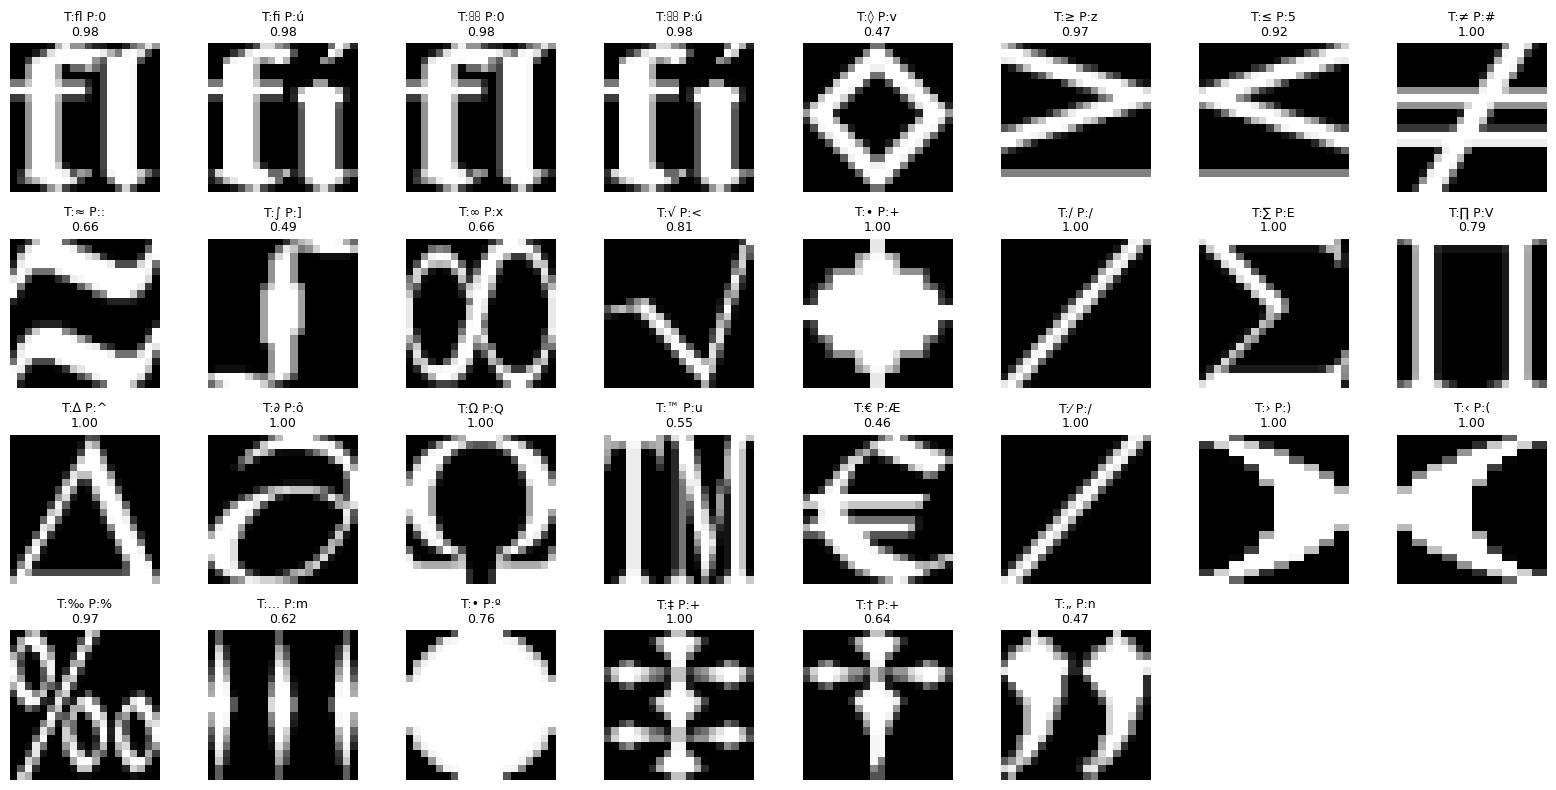

In [37]:
def showMisclassified(model, X, Y, idxToLabel, device='mps', max_images=64):
    model.eval()

    XTensor = torch.tensor(X, dtype=torch.float32).to(device)
    YTensor = torch.tensor(Y, dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(XTensor)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

    # Indices of misclassified samples
    misclassified = (preds != YTensor).nonzero(as_tuple=True)[0]
    num_to_show = min(len(misclassified), max_images)

    plt.figure(figsize=(16, 8))
    for i in range(num_to_show):
        idx = misclassified[i].item()
        image = XTensor[idx].cpu().squeeze().numpy()
        trueLabel = chr(idxToLabel[YTensor[idx].item()])
        predLabel = chr(idxToLabel[preds[idx].item()])
        confidence = probs[idx][preds[idx]].item()

        cols = 8
        rows = (num_to_show // cols) + 1
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(image, cmap='gray')
        ax.set_title(f"T:{trueLabel} P:{predLabel}\n{confidence:.2f}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


showMisclassified(Net, unseenXs, unseenYs, idxToLabel, device=device, max_images=30)


Take a look at some of the characters that have been misclassified. Do you notice any patterns? The network only produces the relative probabilities that the input is any of the possible characters. Can you find examples where the network is unsure of the result?

Answer: I've noticed that the images it predicts incorrectly are either very small versions of something that it predicts or things that aren't even supported by matplot, in these cases, I don't understand how we can really see how it goes wrong. There are many cases where the network isn't sure. However, it's impressive that it's getting close to classifying characters that likely don't exist in it's vocabulary. There are plenty of cases where the network is unsure of what's classifying, but we can see how the images it deciding between can build up the full picture. For example, there is this g like shape that has an additional loop on the bottom of it along the bottom of the image, the classifier says it's top four results are a: 'g', ',','little o' , and a '.' . To me all of these things build up the image, but our trained model doesn't have this in it's vocabaulary, very cool!

Step 4: Denoising
Next we'll build and train a neural network (an autoencoder) for a different task: denoising images.

Next, create and train a convolutional autoencoder to denoise these images. The autoencoder network will probably be similar to the one we made in class, but then you train it, the inputs should be your noisy images (original image + some guassian (normal) noise added), and the expected outputs should be the "clean" images. It might be easiest to make a new NP array with the added noise.

Create a plot showing the noisy and denoised versions of some inputs to verify that your denoiser had the desired effect.

In [91]:

class CnnNet(nn.Module):
    def __init__(self):
        super(CnnNet, self).__init__()
        
        self.encodedSize = 32
        
        self.c1Out = 8 # filters from first conv layer
        self.c2Out = 8 # filters from 2nd conv layer
        
        #the padding here puts a "border" of 0s around the image, so that convolution layers don't "shrink" the image
        
        self.conv1 = nn.Conv2d(1, self.c1Out, 3, padding=1) #stick with 3x3 filters
        #output is 8x 28x28 images
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(self.c1Out, self.c2Out, 3, padding=1)
        #reuse pool here
        
        self.downscaledSize = 20//4 #we add padding, so the conv2d layers don't change the size, just the max pools
        self.flattenedSize = self.downscaledSize*self.downscaledSize*self.c2Out
        
        self.fc1 = nn.Linear(self.flattenedSize, 64)
        self.fc2 = nn.Linear(64, self.encodedSize) #scale down to 64 features

        #now we're encoded, so go define decoding pieces
        
        self.fc3 = nn.Linear(self.encodedSize, 64) #scale down to 64 features
        self.fc4 = nn.Linear(64, self.flattenedSize)
        
        
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')
        # the padding is very important here so we don't have to guess a "frame" of pixels around the image
        self.conv3 = nn.Conv2d(self.c2Out, self.c1Out, 3, padding=1)
        # apply upsample again
        self.conv4 = nn.Conv2d(self.c1Out, 1, 3, padding=1)
        
        
    def compress(self, x):
        x = self.conv1(x)
        #print("shape after conv1", x.shape)
        x = F.relu(self.pool(x))
        #print("shape after pool1", x.shape)
        x = self.conv2(x)
        #print("after conv2", x.shape)
        x = F.relu(self.pool(x))
        #print("after pool 2", x.shape)
        x = x.view(-1, self.flattenedSize)
        #print("flattened shape", x.shape)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        #now we have a low-d representation of our data.  If we were doing compression, we'd store this
        return x
    
    def decompress(self, x):
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        #print(x.shape)
        x = x.view(-1, self.c2Out, self.downscaledSize, self.downscaledSize)
        #print("unflattened shape", x.shape)
        x = self.upsample(x)
        #print("upsample", x.shape)
        x = F.relu(self.conv3(x))
        #print(x.shape, "after cv3")
        x = self.conv4(self.upsample(x))
        #print(x.shape, "after both upsamples")
        return x
    
    def forward(self, x):
        x = self.compress(x)
        x = self.decompress(x)
       
        return x

device = "cpu" # still way slower to use mps for this model ("mps" if torch.backends.mps.is_available() else "cpu")
cnnNet = CnnNet().to(device=device) # treat these as just 28 D vectors

#same as we did before except for the reshaping.  CNNs understand 2D images, so we don't want to flatten

# mean-squared error loss
# this is the normal "least squares" error function, divided by the number of data points
criterion = nn.MSELoss()

def trainCNN(model, trainLoader, epochs):
    
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        running_loss = 0
        
        for  noisyImages, cleanImages in trainLoader:

            noisyImages = noisyImages.to(device)
            cleanImages = cleanImages.to(device)

            optimizer.zero_grad()
            outputs = model(noisyImages)
            loss = criterion(outputs, cleanImages)
            loss.backward()
            optimizer.step()
            # print statistics
            running_loss += loss.item()
        avgEpochLoss = running_loss / len(trainLoader) 
        print(f"Epoch {epoch + 1}, Average Loss: {avgEpochLoss:.4f}")

    

def evaluateCNN(model, testLoader):
    model.eval()
    totalLoss = 0
    with torch.no_grad():
        for noisyImages, cleanImages in testLoader:
            noisyImages = noisyImages.to(device)
            cleanImages = cleanImages.to(device)
            
            outputs = model(noisyImages)
            testLoss = criterion(outputs, cleanImages)
            totalLoss += testLoss.item()
    averageLoss = totalLoss / len(testLoader)
    print(f"Average loss:  {averageLoss:.4f}")


In [92]:
def addNoise(images, noise_factor=0.3):
    noise = noise_factor * torch.randn_like(images) 
    noisyImages = images + noise
    # Ensure pixel values are in [0, 1]
    noisyImages = torch.clip(noisyImages, 0., 1.)  
    return noisyImages

In [93]:
Xs = Xs.reshape(-1, 1, 20, 20) 
Xs = Xs.astype(np.float32)

XsTensor = torch.tensor(Xs)
XsTensor = torch.clamp(XsTensor, 0., 1.)
XTrain, XTest = train_test_split(XsTensor, test_size=0.2, random_state=42)

noisyTrain = addNoise(XTrain)
noisyTest = addNoise(XTest)

trainDataset = TensorDataset(noisyTrain, XTrain)  
testDataset = TensorDataset(noisyTest, XTest)

trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=False)



In [94]:

def drawComparisonsCNN(model, testLoader, device="cpu"):
    model.eval()
    plt.figure(figsize=(20, 6))

    shown = 0
    with torch.no_grad():
        for batch_idx, (noisyImages, cleanImages) in enumerate(testLoader):
            noisyImages = noisyImages.to(device)
            cleanImages = cleanImages.to(device)

            outputs = model(noisyImages)

            for i in range(len(noisyImages)):
                if shown >=  8:
                    break

                # Draw the noisy image clean
                ax = plt.subplot(3, 8, shown + 1)
                ax.imshow(noisyImages[i].cpu().squeeze(), cmap='gray')
                ax.set_title("Noisy", fontsize=8)
                ax.axis('off')

                # Denoised output
                ax = plt.subplot(3, 8, shown + 1 + 8)
                ax.imshow(outputs[i].cpu().squeeze(), cmap='gray')
                ax.set_title("Denoised", fontsize=8)
                ax.axis('off')

                # Clean image
                ax = plt.subplot(3, 8, shown + 1 + 16)
                ax.imshow(cleanImages[i].cpu().squeeze(), cmap='gray')
                ax.set_title("Clean", fontsize=8)
                ax.axis('off')

                shown += 1
                if shown >= 3 * 8:
                    break

    plt.tight_layout()
    plt.show()


Epoch 1, Average Loss: 0.1188
Epoch 2, Average Loss: 0.0927
Epoch 3, Average Loss: 0.0791
Epoch 4, Average Loss: 0.0714
Epoch 5, Average Loss: 0.0671
Epoch 6, Average Loss: 0.0643
Epoch 7, Average Loss: 0.0619
Epoch 8, Average Loss: 0.0599
Epoch 9, Average Loss: 0.0584
Epoch 10, Average Loss: 0.0571
Epoch 11, Average Loss: 0.0562
Epoch 12, Average Loss: 0.0551
Epoch 13, Average Loss: 0.0543
Epoch 14, Average Loss: 0.0535
Epoch 15, Average Loss: 0.0528
Epoch 16, Average Loss: 0.0521
Epoch 17, Average Loss: 0.0513
Epoch 18, Average Loss: 0.0506
Epoch 19, Average Loss: 0.0499
Epoch 20, Average Loss: 0.0493
Epoch 21, Average Loss: 0.0488
Epoch 22, Average Loss: 0.0482
Epoch 23, Average Loss: 0.0478
Epoch 24, Average Loss: 0.0473
Epoch 25, Average Loss: 0.0468
Epoch 26, Average Loss: 0.0465
Epoch 27, Average Loss: 0.0461
Epoch 28, Average Loss: 0.0457
Epoch 29, Average Loss: 0.0454
Epoch 30, Average Loss: 0.0451
Average loss:  0.0458


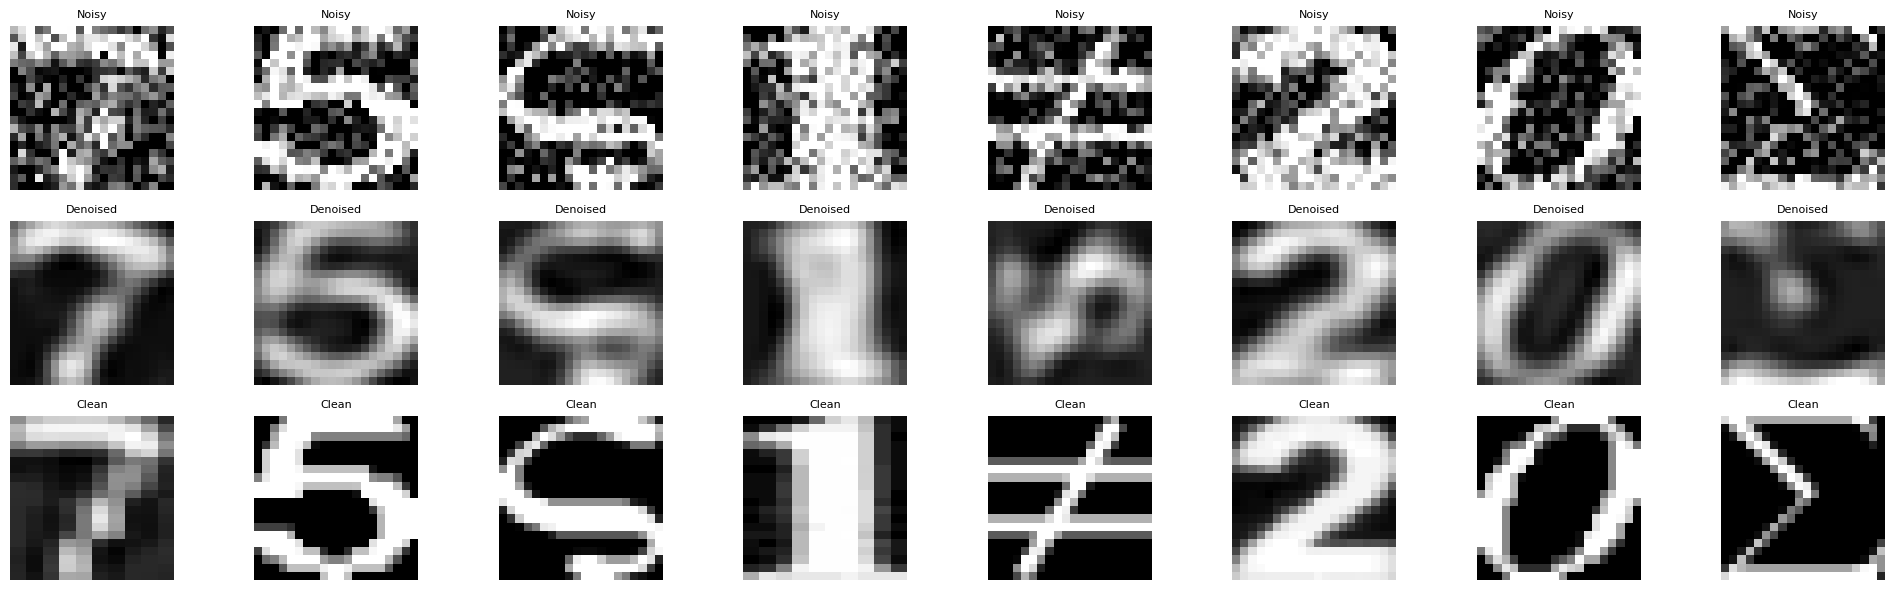

In [96]:
trainCNN(cnnNet, trainLoader,epochs=30)
evaluateCNN(cnnNet, testLoader)
drawComparisonsCNN(cnnNet, testLoader, device=device)

Well the model was super clean with a consistent change in loss. Overall, a super cool look at denoising, it would be great to see this in action on some more extreme efforts like trying to figureif someone on a camera was the correct person accused!